# Notebook for fuckaroundary

## plot examples of mask to verify 

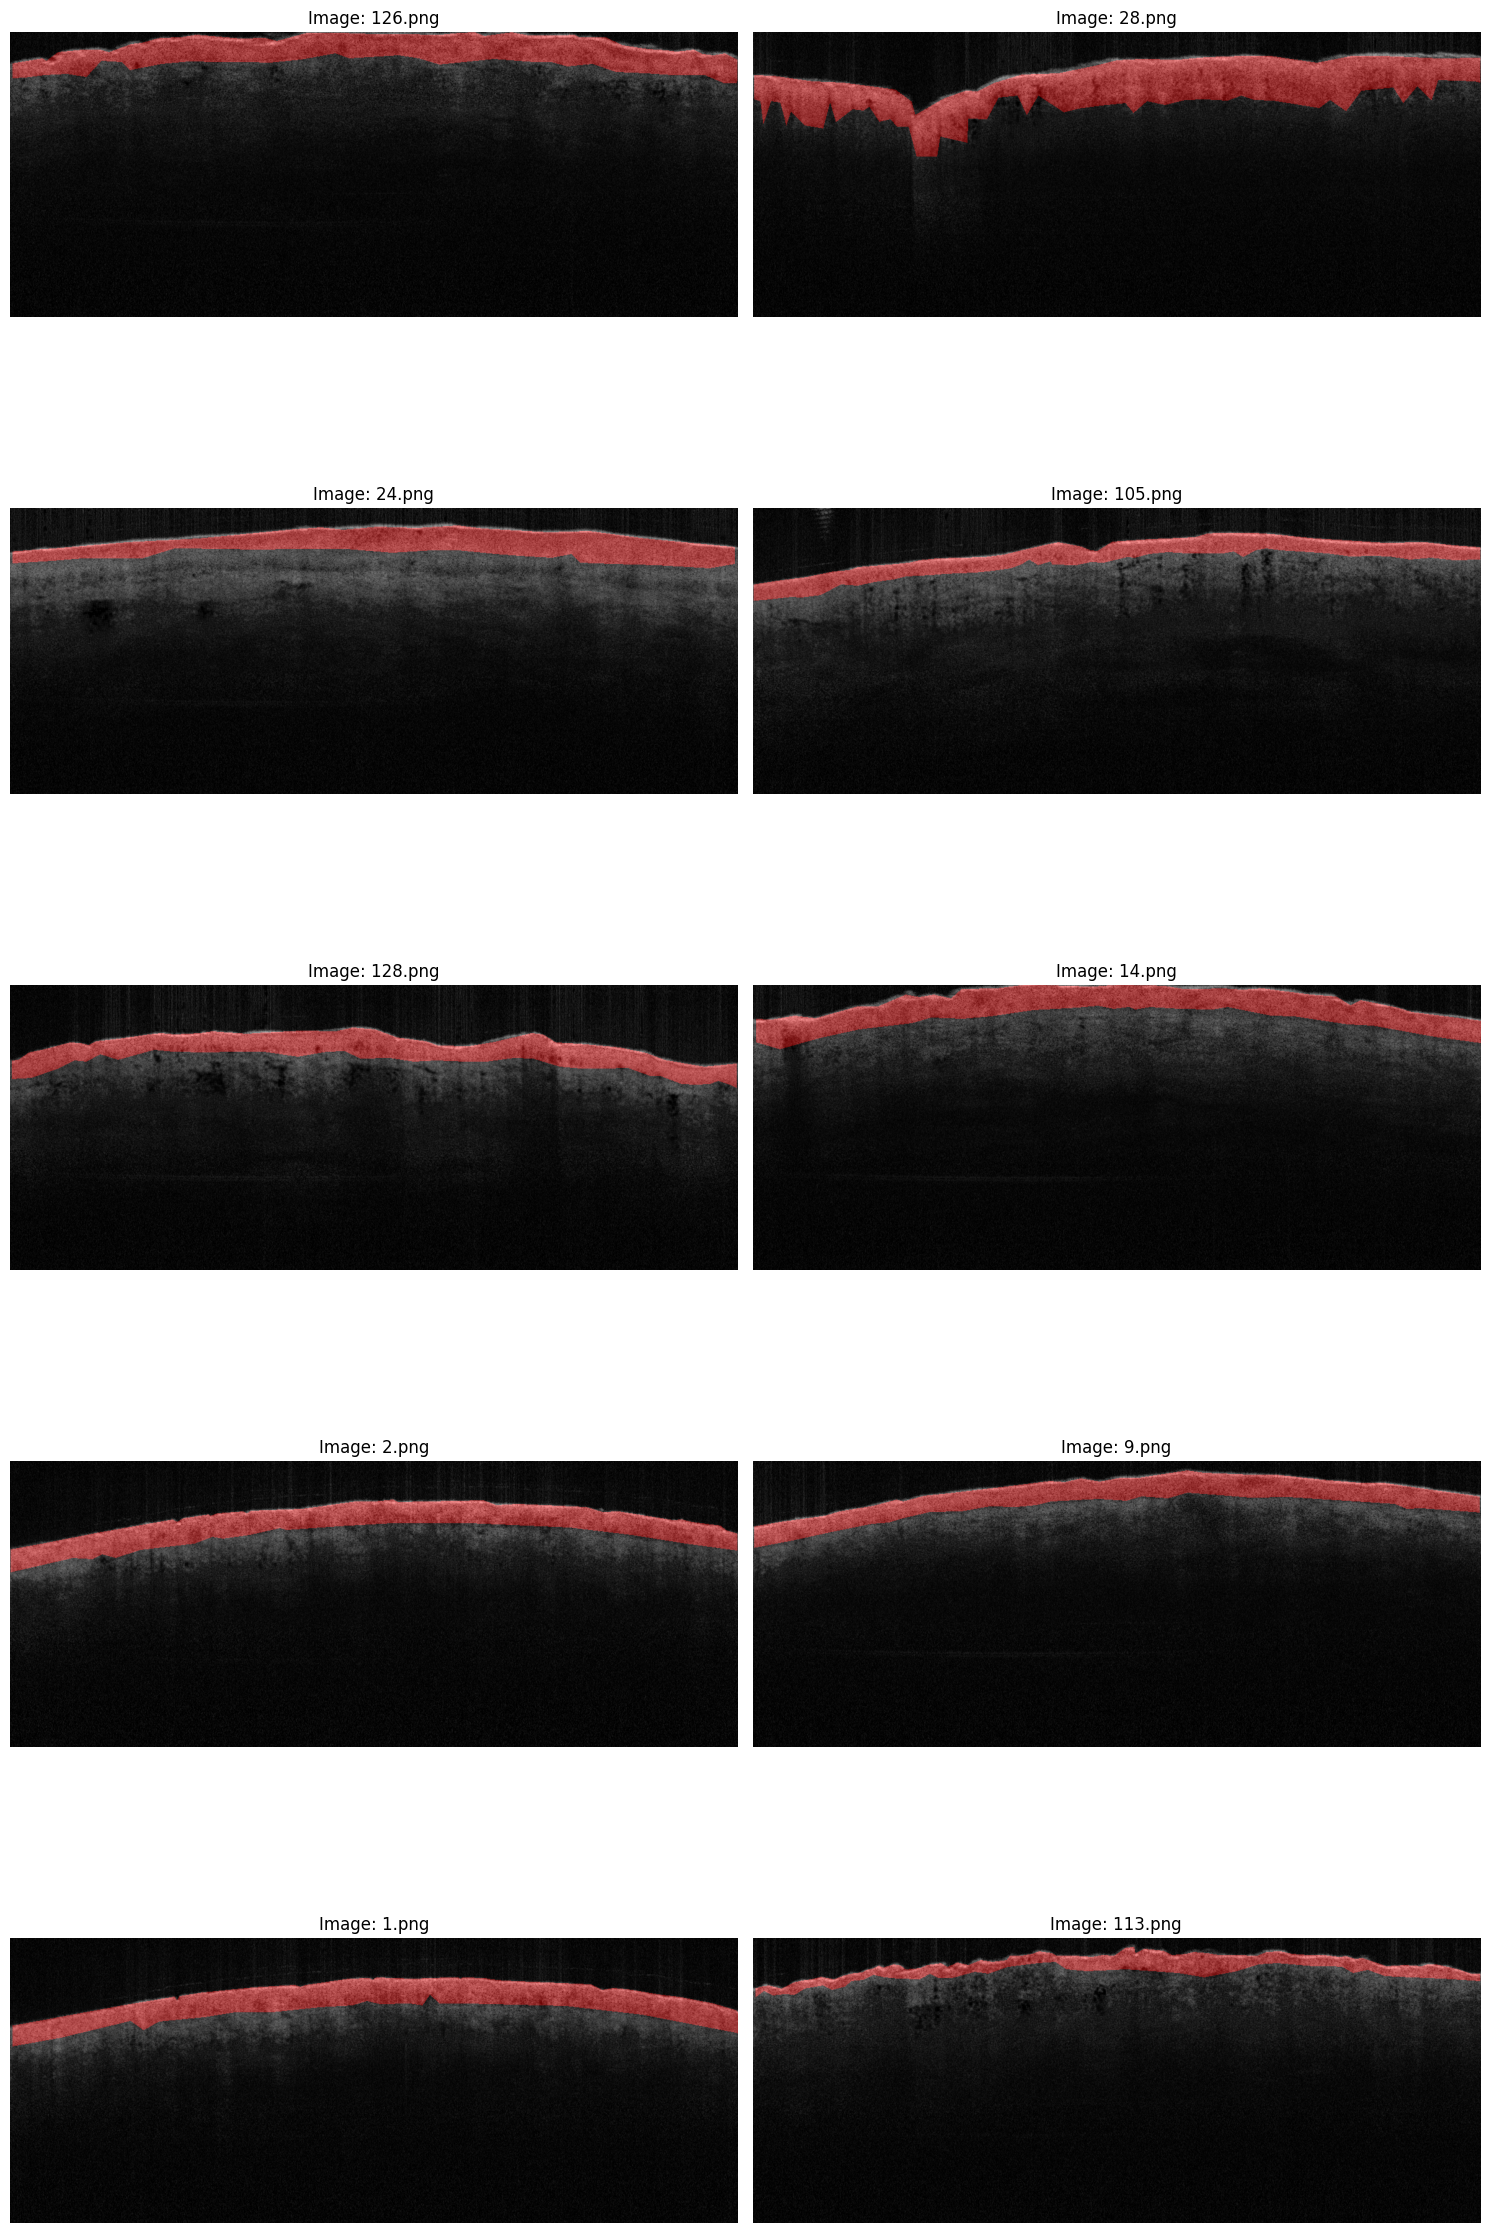

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

# Paths
PATH_TO_IMAGES = Path("../data/for_segmentation/images")
PATH_TO_MASKS = Path("../data/for_segmentation/masks")

# Get list of images and masks
image_files = sorted(list(PATH_TO_IMAGES.glob("*.png")))
# Filter out those that have a corresponding mask
valid_pairs = []
for img_path in image_files:
    img_name = img_path.stem
    mask_path = PATH_TO_MASKS / f"mask_{img_name}.png"
    if mask_path.exists():
        valid_pairs.append((img_path, mask_path))

# Select 10 random samples
if len(valid_pairs) >= 10:
    samples = random.sample(valid_pairs, 10)
else:
    samples = valid_pairs

# Plot
n_samples = len(samples)
cols = 2
rows = (n_samples + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, (img_path, mask_path) in enumerate(samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    # Create an overlay
    overlay = img.copy()
    # Create a red (hot) mask: R=255, G=0, B=0
    red_mask = np.zeros_like(img)
    red_mask[mask == 255] = [255, 0, 0]
    
    # Blend the original image with the red mask
    alpha = 0.4
    cv2.addWeighted(red_mask, alpha, overlay, 1 - alpha, 0, overlay)
    
    axes[i].imshow(overlay)
    axes[i].set_title(f"Image: {img_path.name}")
    axes[i].axis('off')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()